# Preprocessing QC summary


In [5]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

# --- set your file path here ---
# csv_path = "/cluster/project/reddy/katja/NGS_pipeline/data/P3481_LUCA-TCRDMF5/preprocessed/18_02_2026_minLenght110_QScore20/bbduk_summary_20260218_104832.csv"   # <-- change
# csv_path = "/cluster/project/reddy/katja/NGS_pipeline/data/P3408_LUCA-TCRA3/processed/27_01_2026_minLenght191_QScore20/bbduk_summary_20260127_11-27-18.csv"   # <-- change
csv_path = "/cluster/project/reddy/katja/NGS_pipeline/data/P3408_LUCA-TCRA3/processed/10_05_2026_minLenght191_QScore30/bbduk_run_summary_20260510_212407.csv"   # <-- change

df = pd.read_csv(csv_path)
df.head()


,sample_id,sample_name,sample_label,input_fastq,output_fastq,output_size_bytes,bbduk_version,reads_in,bases_in,reads_out,bases_out,reads_removed,bases_removed,reads_qtrimmed,bases_qtrimmed,runtime_s
0,GFB-61811,clibMAGE-A32xnegative,GFB-61811_clibMAGE-A32xnegative,/cluster/project/reddy/marluca/NGS_pipeline/da...,/cluster/project/reddy/katja/NGS_pipeline/data...,1259951574,39.33,31276031,6255206200,9934444,1968147449,21341587,4287058751,24495698,4287058751,84.338860
1,GFB-61811,clibMAGE-A32xnegative,GFB-61811_clibMAGE-A32xnegative,/cluster/project/reddy/marluca/NGS_pipeline/da...,/cluster/project/reddy/katja/NGS_pipeline/data...,661031359,39.33,16957339,3391467800,5529509,1097185761,11427830,2294282039,13001895,2294282039,41.412699
2,GFB-61811,clibMAGE-A32xnegative,GFB-61811_clibMAGE-A32xnegative,/cluster/project/reddy/marluca/NGS_pipeline/da...,/cluster/project/reddy/katja/NGS_pipeline/data...,1689074851,39.33,41011350,8202270000,14233896,2824519855,26777454,5377750145,30789465,5377750145,111.475001
3,GFB-61811,clibMAGE-A32xnegative,GFB-61811_clibMAGE-A32xnegative,/cluster/project/reddy/marluca/NGS_pipeline/da...,/cluster/project/reddy/katja/NGS_pipeline/data...,767396367,39.33,20811611,4162322200,6826144,1356339002,13985467,2805983198,15680068,2805983198,50.311507
4,GFB-61812,clibTitin2xnegative,GFB-61812_clibTitin2xnegative,/cluster/project/reddy/marluca/NGS_pipeline/da...,/cluster/project/reddy/katja/NGS_pipeline/data...,922001043,39.33,20788874,4157774800,7174151,1421269995,13614723,2736504805,15884000,2736504805,55.022563


In [6]:
# Ensure numeric cols are numeric (in case they were read as strings)
num_cols = [
    "output_size_bytes",
    "reads_in","bases_in","reads_out","bases_out",
    "reads_removed","bases_removed",
    "reads_qtrimmed","bases_qtrimmed",
    "runtime_s"
]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Derive run_id from the input_fastq path: ".../run1-1000M/..." -> "run1-1000M"
def extract_run_id(p):
    if pd.isna(p):
        return np.nan
    m = re.search(r"/(run\d+-[^/]+)/", str(p))
    return m.group(1) if m else np.nan

df["run_id"] = df["input_fastq"].apply(extract_run_id)

# Optional: lane from filename "..._L001_..." -> "L001"
def extract_lane(p):
    if pd.isna(p):
        return np.nan
    m = re.search(r"_L(\d{3})_", str(p))
    return f"L{m.group(1)}" if m else np.nan

df["lane"] = df["input_fastq"].apply(extract_lane)

# Helpful QC metrics (guard against division by zero)
df["retention_reads_pct"] = 100 * df["reads_out"] / df["reads_in"]
df["retention_bases_pct"] = 100 * df["bases_out"] / df["bases_in"]
df["avg_read_len_in"] = df["bases_in"] / df["reads_in"]
df["avg_read_len_out"] = df["bases_out"] / df["reads_out"]
df["throughput_reads_per_s"] = df["reads_in"] / df["runtime_s"]
df["qtrim_share_of_removed_reads_pct"] = 100 * df["reads_qtrimmed"] / df["reads_removed"].replace(0, np.nan)

df[["sample_id","sample_name","run_id","lane","reads_in","reads_out","retention_reads_pct","runtime_s"]].head()


,sample_id,sample_name,run_id,lane,reads_in,reads_out,retention_reads_pct,runtime_s
0,GFB-61811,clibMAGE-A32xnegative,run1-1000M,L001,31276031,9934444,31.763762,84.338860
1,GFB-61811,clibMAGE-A32xnegative,run2-500M,L001,16957339,5529509,32.608353,41.412699
2,GFB-61811,clibMAGE-A32xnegative,run1-1000M,L002,41011350,14233896,34.707212,111.475001
3,GFB-61811,clibMAGE-A32xnegative,run2-500M,L002,20811611,6826144,32.799691,50.311507
4,GFB-61812,clibTitin2xnegative,run1-1000M,L001,20788874,7174151,34.509570,55.022563


In [7]:
group_cols = ["sample_id", "sample_name", "sample_label"]

sample_summary = (
    df.groupby(group_cols, dropna=False)
      .agg(
          n_rows=("input_fastq","count"),
          n_runs=("run_id", pd.Series.nunique),
          n_lanes=("lane", pd.Series.nunique),
          reads_in=("reads_in","sum"),
          reads_out=("reads_out","sum"),
          reads_removed=("reads_removed","sum"),
          reads_qtrimmed=("reads_qtrimmed","sum"),
          bases_in=("bases_in","sum"),
          bases_out=("bases_out","sum"),
          bases_removed=("bases_removed","sum"),
          bases_qtrimmed=("bases_qtrimmed","sum"),
          output_size_bytes=("output_size_bytes","sum"),
          runtime_s=("runtime_s","sum"),
      )
      .reset_index()
)

# Derived metrics on the aggregates
sample_summary["retention_reads_pct"] = 100 * sample_summary["reads_out"] / sample_summary["reads_in"]
sample_summary["retention_bases_pct"] = 100 * sample_summary["bases_out"] / sample_summary["bases_in"]
sample_summary["avg_read_len_in"] = sample_summary["bases_in"] / sample_summary["reads_in"]
sample_summary["avg_read_len_out"] = sample_summary["bases_out"] / sample_summary["reads_out"]
sample_summary["throughput_reads_per_s"] = sample_summary["reads_in"] / sample_summary["runtime_s"]

ENR_TOKEN = r"(?:POISITIVE|POITIVE|POSITVE|POSITIVE|NEGAITIVE|NEGTAIVE|NEGATIVE)"
dataset_is_dmf5 = "DMF5" in str(csv_path).upper()

def detect_name_scheme(sample_name):
    s = str(sample_name).upper()
    if re.search(r"GIG\s*0*\d+|DRG\s*0*\d+", s):
        return "legacy"
    if re.search(r"KH\s*[-_ ]?\d{3}", s) or re.search(r"\bMAGE[-_ ]?A?3\b", s) or "TITIN" in s or "TININ" in s:
        return "kh_style"
    return "unknown"

def _normalize_enrichment(enr):
    if not enr:
        return "unknown"
    enr = str(enr).upper()
    enr = re.sub(r"[\s_\-]+", "", enr)
    enr = enr.replace("POISITIVE", "POSITIVE").replace("POITIVE", "POSITIVE").replace("POSITVE", "POSITIVE")
    enr = enr.replace("NEGAITIVE", "NEGATIVE").replace("NEGTAIVE", "NEGATIVE")
    enr = enr.replace(",", "")
    m = re.search(r"(\d+)X(POSITIVE|NEGATIVE)", enr)
    if not m:
        return "unknown"
    return f"{int(m.group(1))}x{m.group(2).lower()}"

def parse_protein_and_enrichment(sample_name):
    s = str(sample_name).upper()

    if "ORILIB" in s or "ORIGINALLIB" in s or "ORIGINAL" in s:
        return "ORILIB", "original lib"

    scheme = detect_name_scheme(sample_name)

    # Handle compact names where peptide token is directly followed by enrichment,
    # e.g. KH1582xnegative or MAGE-A32xpositive.
    m_gig_combo = re.search(rf"GIG0*(\d+)(?=(\d+\s*X\s*{ENR_TOKEN}))", s)
    if m_gig_combo:
        return f"GIG{int(m_gig_combo.group(1)):02d}", _normalize_enrichment(m_gig_combo.group(2))

    m_drg_combo = re.search(rf"DRG0*(\d+)(?=(\d+\s*X\s*{ENR_TOKEN}))", s)
    if m_drg_combo:
        return f"DRG{int(m_drg_combo.group(1)):02d}", _normalize_enrichment(m_drg_combo.group(2))

    m_kh_combo = re.search(rf"KH\s*[-_ ]?(\d{{3}})(?=(\d+\s*X\s*{ENR_TOKEN}))", s)
    if m_kh_combo:
        return f"KH{int(m_kh_combo.group(1)):03d}", _normalize_enrichment(m_kh_combo.group(2))

    m_mage_combo = re.search(rf"MAGE[-_ ]?A?3(?=(\d+\s*X\s*{ENR_TOKEN}))", s)
    if m_mage_combo:
        return "MAGE-A3", _normalize_enrichment(m_mage_combo.group(1))

    m_titin_combo = re.search(rf"(?:TITIN|TININ)(?=(\d+\s*X\s*{ENR_TOKEN}))", s)
    if m_titin_combo:
        return "TITIN", _normalize_enrichment(m_titin_combo.group(1))

    # Fallback: find protein token and enrichment anywhere.
    m_gig = re.search(r"GIG\s*0*(\d+)(?!\d)", s)
    if m_gig:
        protein = f"GIG{int(m_gig.group(1)):02d}"
    else:
        m_drg = re.search(r"DRG\s*0*(\d+)(?!\d)", s)
        if m_drg:
            protein = f"DRG{int(m_drg.group(1)):02d}"
        else:
            m_kh = re.search(r"KH\s*[-_ ]?(\d{3})(?!\d)", s)
            if m_kh:
                protein = f"KH{int(m_kh.group(1)):03d}"
            elif re.search(r"\bMAGE[-_ ]?A?3\b", s):
                protein = "MAGE-A3"
            elif "TITIN" in s or "TININ" in s:
                protein = "TITIN"
            else:
                protein = "UNKNOWN"

    m_enr = re.search(rf"(\d+)\s*X\s*{ENR_TOKEN}", s)
    enrich = _normalize_enrichment(m_enr.group(0)) if m_enr else "unknown"

    # KH/TITIN/MAGE-A3 dataset has a constrained enrichment set; legacy remains open.
    if scheme == "kh_style":
        allowed = {"2xnegative", "3xpositive", "31xpositive"}
        if protein in {"TITIN", "MAGE-A3"}:
            allowed.add("2xpositive")
        if enrich not in allowed and enrich != "unknown":
            enrich = "unknown"

    return protein, enrich

def enrichment_rank(enrich, protein=None, dmf5=False):
    p = str(protein).upper() if protein is not None else ""
    if enrich == "original lib":
        return 0

    # For TITIN/MAGE-A3: enforce 2xnegative before 2xpositive.
    if p in {"TITIN", "MAGE-A3"}:
        order = {
            "2xnegative": 1,
            "2xpositive": 2,
            "3xpositive": 3,
            "31xpositive": 4,
        }
        if enrich in order:
            return order[enrich]

    # For DMF5 datasets: enforce 2xnegative, 1xpositive, 2xpositive.
    if dmf5:
        order = {
            "2xnegative": 1,
            "1xpositive": 2,
            "2xpositive": 3,
        }
        if enrich in order:
            return order[enrich]

    if enrich == "1xpositive":
        return 1
    if enrich == "2xpositive":
        return 2
    if enrich == "2xnegative":
        return 3
    if enrich == "3xpositive":
        return 4
    if enrich == "31xpositive":
        return 5
    m = re.match(r"(\d+)x(positive|negative)", str(enrich), flags=re.IGNORECASE)
    if m:
        n = int(m.group(1))
        sign = m.group(2).lower()
        return 10 + (n * 2) + (0 if sign == "positive" else 1)
    return 999

def protein_sort_parts(protein):
    p = str(protein).upper()
    m = re.match(r"^GIG0*(\d+)$", p)
    if m:
        return 0, "GIG", int(m.group(1)), p
    m = re.match(r"^DRG0*(\d+)$", p)
    if m:
        return 1, "DRG", int(m.group(1)), p
    m = re.match(r"^KH(\d{3})$", p)
    if m:
        return 2, "KH", int(m.group(1)), p
    if p == "MAGE-A3":
        return 3, "MAGE-A3", 0, p
    if p == "TITIN":
        return 4, "TITIN", 0, p
    m = re.match(r"^([A-Z]+)0*(\d+)$", p)
    if m:
        return 5, m.group(1), int(m.group(2)), p
    if p == "ORILIB":
        return 98, "ORILIB", 0, p
    return 99, p, 999999, p

parsed = sample_summary["sample_name"].apply(parse_protein_and_enrichment)
sample_summary[["protein", "enrichment"]] = pd.DataFrame(parsed.tolist(), index=sample_summary.index)
sample_summary["enrichment_rank"] = sample_summary.apply(
    lambda r: enrichment_rank(r["enrichment"], r["protein"], dataset_is_dmf5), axis=1
)
sample_summary[["protein_group", "protein_prefix", "protein_number", "protein_raw"]] = pd.DataFrame(
    sample_summary["protein"].apply(protein_sort_parts).tolist(), index=sample_summary.index
)
sample_summary["display_label"] = sample_summary["protein"] + " " + sample_summary["enrichment"]

plot_summary = sample_summary.sort_values(
    ["protein_group", "protein_prefix", "protein_number", "protein_raw", "enrichment_rank", "sample_label"],
    ascending=[True, True, True, True, True, True]
).reset_index(drop=True)

plot_summary[["display_label", "protein", "enrichment", "reads_in", "reads_out", "retention_reads_pct"]].head(20)

,display_label,protein,enrichment,reads_in,reads_out,retention_reads_pct
0,KH157 2xnegative,KH157,2xnegative,271495194,209511828,77.169627
1,KH157 3xpositive,KH157,3xpositive,11187609,8128960,72.660387
2,KH157 31xpositive,KH157,31xpositive,11077455,7273283,65.658430
3,KH158 2xnegative,KH158,2xnegative,82776670,31331769,37.850966
4,KH158 3xpositive,KH158,3xpositive,8011224,3434860,42.875596
5,KH158 31xpositive,KH158,31xpositive,17264280,8251242,47.793722
6,KH159 2xnegative,KH159,2xnegative,112056719,45711036,40.792767
7,KH159 3xpositive,KH159,3xpositive,6001466,2613139,43.541678
8,KH159 31xpositive,KH159,31xpositive,13694509,6382047,46.602963
9,KH160 2xnegative,KH160,2xnegative,68232292,24620388,36.083191


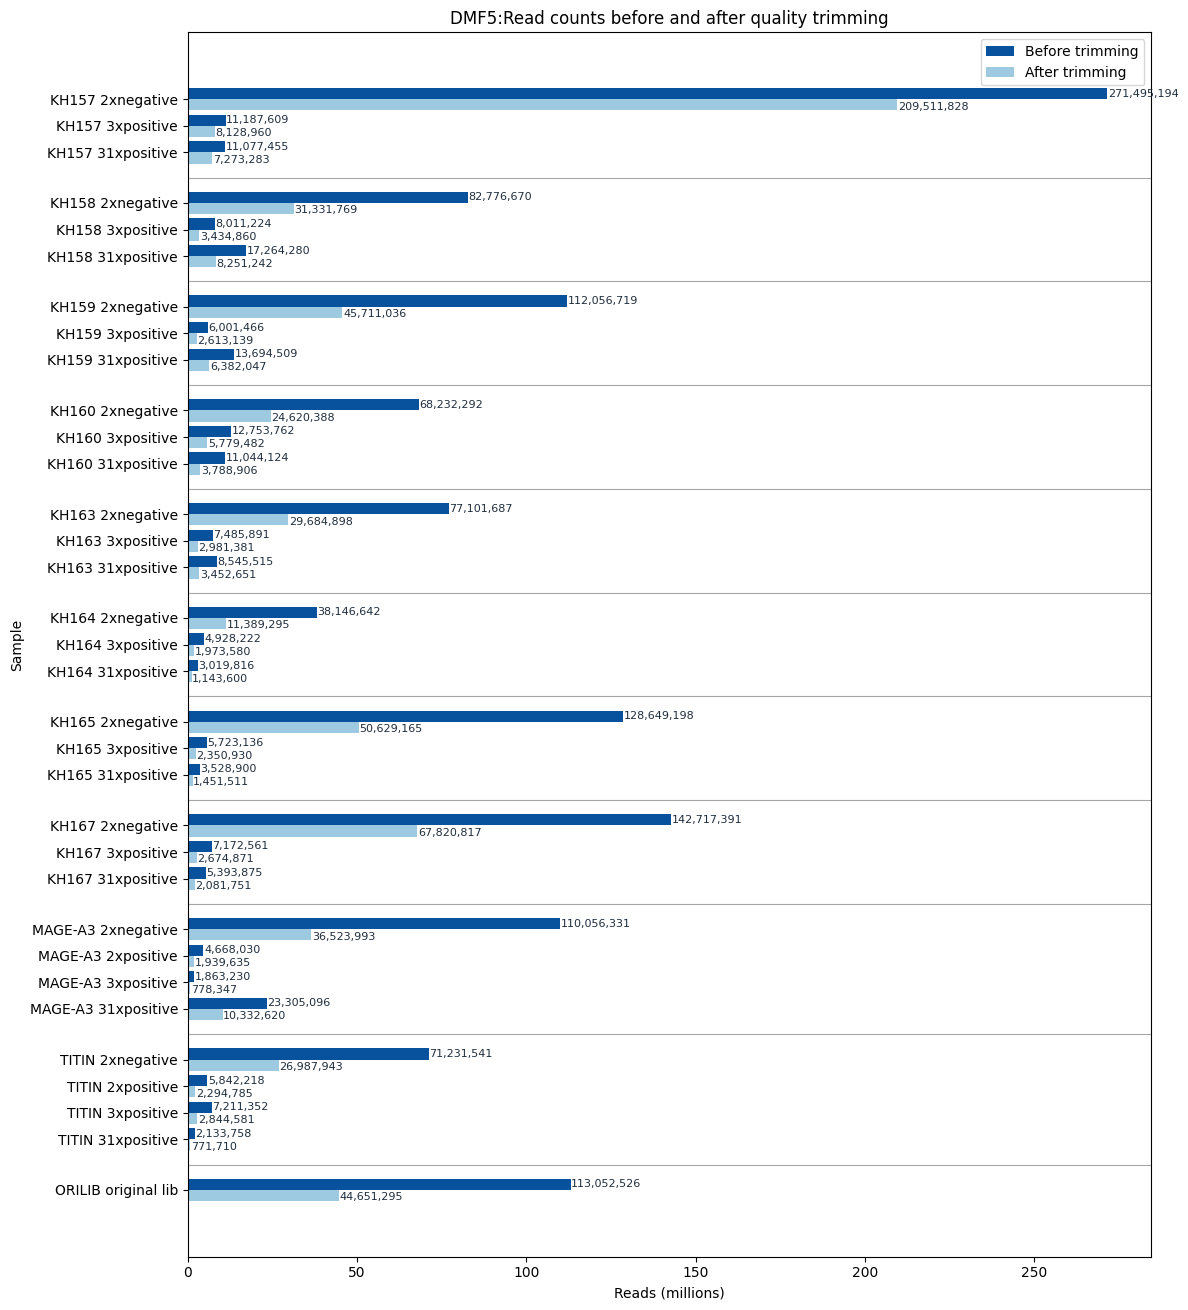

In [8]:
ordered = plot_summary.copy()

# Build y positions with a gap between peptide groups for readability.
group_gap = 0.9
group_starts = np.where(ordered["protein"].ne(ordered["protein"].shift(1)))[0]
y = np.arange(len(ordered), dtype=float)
for s in group_starts[1:]:
    y[s:] += group_gap

# Plot in millions of reads to keep axes readable.
reads_in_m = ordered["reads_in"] / 1_000_000
reads_out_m = ordered["reads_out"] / 1_000_000
h = 0.42

fig, ax = plt.subplots(figsize=(12, max(5, 0.4 * len(ordered))))
# Keep "before" as dark blue and on the upper bar of each pair.
ax.barh(y - h / 2, reads_in_m, height=h, label="Before trimming", color="#08519c")
ax.barh(y + h / 2, reads_out_m, height=h, label="After trimming", color="#9ecae1")

for s in group_starts[1:]:
    sep_y = (y[s - 1] + y[s]) / 2
    ax.axhline(sep_y, color="black", linewidth=0.8, alpha=0.35)

# Add actual read counts at the end of each bar.
for yi, reads_before_m, reads_after_m, reads_before, reads_after in zip(
    y, reads_in_m, reads_out_m, ordered["reads_in"], ordered["reads_out"]
):
    ax.text(reads_before_m + 0.15, yi - h / 2, f"{int(reads_before):,}", va="center", ha="left", fontsize=8, color="#1f2d3d")
    ax.text(reads_after_m + 0.15, yi + h / 1.5, f"{int(reads_after):,}", va="center", ha="left", fontsize=8, color="#1f2d3d")

x_max_m = max(float(reads_in_m.max()), float(reads_out_m.max())) + 13
ax.set_xlim(0, x_max_m)
ax.set_yticks(y, ordered["display_label"].astype(str))
ax.set_xlabel("Reads (millions)")
ax.set_ylabel("Sample")
ax.set_title("DMF5:Read counts before and after quality trimming")
ax.legend(loc="upper right")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
ordered = plot_summary.copy()

# Use the same grouped spacing by peptide as the read count plot.
group_gap = 0.9
group_starts = np.where(ordered["protein"].ne(ordered["protein"].shift(1)))[0]
y = np.arange(len(ordered), dtype=float)
for s in group_starts[1:]:
    y[s:] += group_gap

# Softer threshold colors: low retention, medium retention, high retention.
colors = [
    "#ffb657" if x < 50 else
    "#2954aa" if x < 70 else
    "#00656c"
    for x in ordered["retention_reads_pct"]
]

fig, ax = plt.subplots(figsize=(12, max(4, 0.40 * len(ordered))))
bars = ax.barh(y, ordered["retention_reads_pct"], color=colors)

for s in group_starts[1:]:
    sep_y = (y[s - 1] + y[s]) / 2
    ax.axhline(sep_y, color="black", linewidth=0.8, alpha=0.35)

ax.axvline(50, linestyle="--", linewidth=1, color="#8c8c8c")
ax.axvline(70, linestyle="--", linewidth=1, color="#8c8c8c")

x_max = max(100, float(ordered["retention_reads_pct"].max()) + 18)
ax.set_xlim(0, x_max)
ax.set_yticks(y, ordered["display_label"].astype(str))
ax.set_xlabel("Read retention [%]")
ax.set_ylabel("Sample")
ax.set_title("Read retention after preprocessing (grouped by peptide)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()